# CNN 심화

In [5]:
import keras

In [6]:
model = keras.models.load_model('best-model.keras')

In [7]:
model.layers

[<Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Conv2D name=conv2d_3, built=True>,
 <MaxPooling2D name=max_pooling2d_3, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_3, built=True>]

In [8]:
conv = model.layers[0]

In [9]:
conv.weights[0].shape # 가중치 w 3 * 3 * 1 * 32 = 288, 모델이 필터 크기만큼 학습한 수

TensorShape([3, 3, 1, 32])

In [10]:
conv.weights[1].shape # 가중치 b : 32, 필터 개수만큼 편향 1개

TensorShape([32])

In [11]:
conv_weights = conv.weights[0].numpy()

In [12]:
conv_weights.mean(), conv_weights.std() # 평균, 표준편차

(np.float32(-0.011136169), np.float32(0.2110164))

In [13]:
# 학습하지 않은 모델
no_train_model = keras.Sequential()
no_train_model.add(keras.layers.Input(shape=(28,28,1)))
no_train_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [14]:
no_train_model.layers

[<Conv2D name=conv2d, built=True>]

In [15]:
# 가중치를 가져옴.
no_train_conv = no_train_model.layers[0]
no_train_weights = no_train_conv.weights[0].numpy()
no_train_weights.mean(), no_train_weights.std()
# 학습 전 후 표준편차을 비교했을 때 --> 표준펀차가 학습 후 증가하였다
# 학습 후 필터들이 여러 종류의 패턴을 감지할 수 있는 능력을 가지게 됐다.

(np.float32(-0.007772742), np.float32(0.08099879))

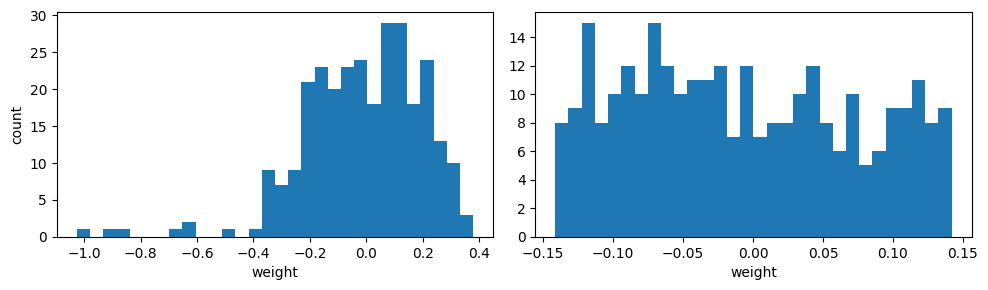

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(conv_weights.reshape(-1), bins=30)
axes[0].set_xlabel('weight'); axes[0].set_ylabel('count')

axes[1].hist(no_train_weights.reshape(-1), bins=30)
axes[1].set_xlabel('weight')

plt.tight_layout(); plt.show()

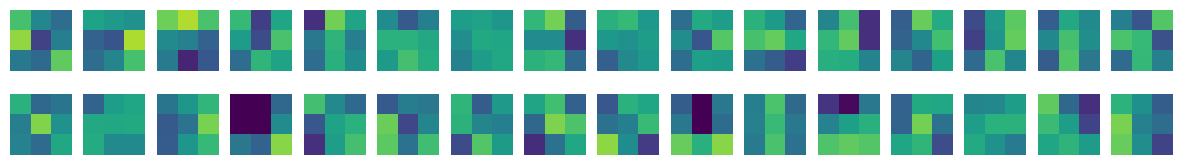

In [17]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:, :, 0, i*16 + j],
                         vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

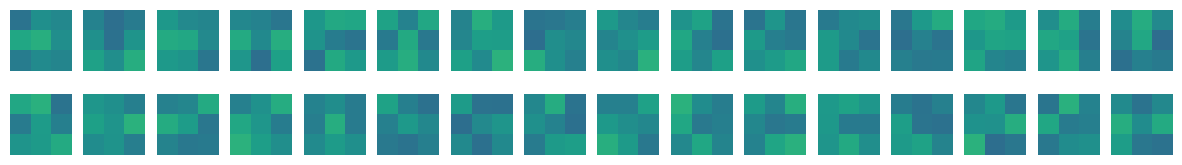

In [18]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_train_weights[:, :, 0, i*16 + j],
                         vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [19]:
# 함수형 API
model_seq = keras.Sequential([
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 함수형 API
inputs= keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

hidden = dense1(inputs) # 함수 호출하듯이 통과 시킴
outputs = dense2(hidden)

func_model = keras.Model(inputs, outputs)

In [20]:
model.inputs[0], model.layers[0].output

(<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_1>,
 <KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor>)

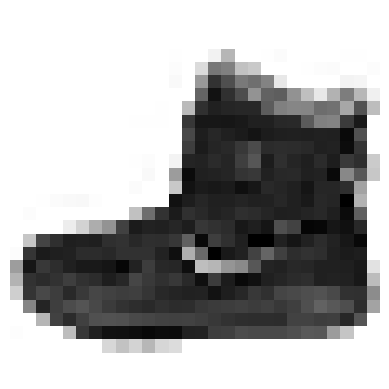

In [21]:
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

plt.imshow(train_input[0], cmap='gray_r')
plt.axis('off')
plt.show()

In [22]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0

NameError: name 'feature_maps1' is not defined

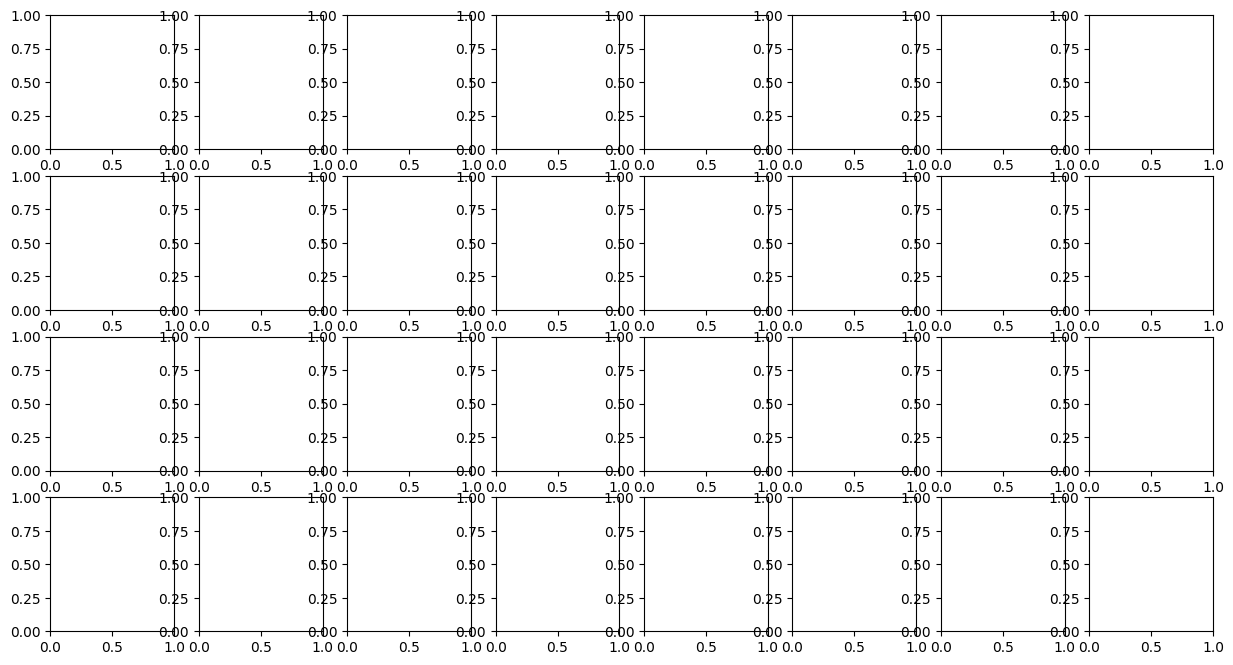

In [23]:
# 2. 1번째 Conv 층 활성화 모델 정의 및 예측 conv1_acti = keras.Model(inputs=model.inputs, outputs=model.layers[0].output) feature_maps1 = conv1_acti.predict(ankle_boot) print("1번째 층 출력 크기:", feature_maps1.shape) # (1, 28, 28, 32) # 3. 4행 8열(32장) 그리드 출력 
fig, axs = plt.subplots(4, 8, figsize=(15, 8)) 
for i in range(4): 
    for j in range(8): 
        axs[i, j].imshow(feature_maps1[0, :, :, i*8 + j], cmap='gray_r') 
        axs[i, j].axis('off') 
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
2번째 층 출력 크기: (1, 14, 14, 64)


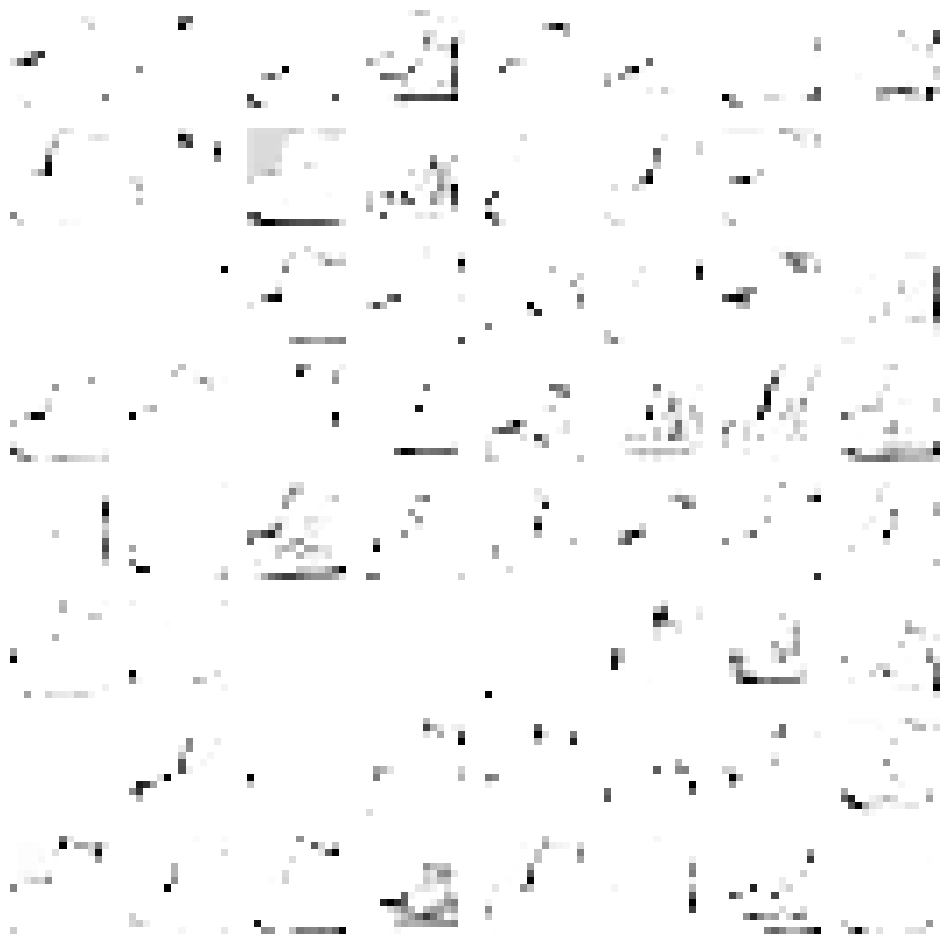

In [ ]:
# 1. 2번째 Conv 층 활성화 모델 정의 및 예측 (인덱스 2번은 MaxPooling을 건너뛰기 위함)
conv2_acti = keras.Model(inputs=model.inputs, outputs=model.layers[2].output)
feature_maps2 = conv2_acti.predict(ankle_boot)

print("2번째 층 출력 크기:", feature_maps2.shape) # (1, 14, 14, 64)

# 2. 8행 8열(64장) 그리드 출력
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps2[0, :, :, i*8 + j], cmap='gray_r')
        axs[i, j].axis('off')
plt.show()

# 데이터 증강

In [24]:
# 데이터 증강 : training 때만 사용, 테스트 때는 사용하지 않음
data_augmentation =  keras.Sequential([
    keras.layers.RandomFlip('horizontal'), # 좌우대칭
    keras.layers.RandomRotation(0.1),      # 10%를 랜덤하게 회전 36도
    keras.layers.RandomZoom(0.1)           # 10%를 확대하거나 축소
])

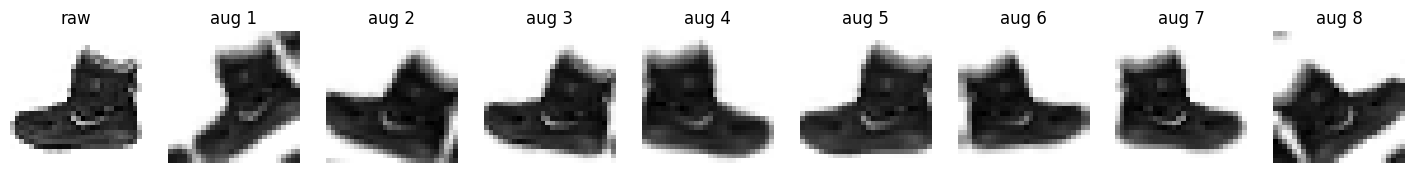

In [27]:
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

(train_input, _), _ = fashion_mnist.load_data()
sample = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0   # ankle boot 1장

fig, axs = plt.subplots(1, 9, figsize=(18, 2))
axs[0].imshow(sample[0, :, :, 0], cmap='gray_r')
axs[0].set_title("raw")
axs[0].axis('off')

for i in range(1, 9):
    augmented = data_augmentation(sample, training=True)  # training=True: 변형 적용
    axs[i].imshow(augmented[0, :, :, 0], cmap='gray_r')
    axs[i].set_title(f"aug {i}")
    axs[i].axis('off')
plt.show()

In [28]:
# 증강된 데이터를 모델에 통합
model_aug = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    data_augmentation,                                         # ← 이 한 줄만 추가
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax'),
])

# 전이 학습

In [30]:
from keras.applications import MobileNetV2

In [33]:
import tensorflow as tf
from keras.datasets import cifar10

# CIFAR-10 로드 (3채널 컬러, 10클래스)
(x_train, y_train_raw), (x_test, y_test_raw) = cifar10.load_data()
y_train = y_train_raw.flatten()   # (50000, 1) → (50000,)
y_test  = y_test_raw.flatten()

# MobileNetV2 최소 입력 크기 96×96 ? CIFAR-10(32×32)을 리사이즈
x_train_r = tf.image.resize(x_train, [96, 96]) / 255.0
x_test_r  = tf.image.resize(x_test,  [96, 96]) / 255.0


In [36]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,  # top Dense 제외
    weights='imagenet'  # ImageNet에서 학습된 가중치 사용
)

In [42]:
# 레이어 갯수, 파라미터 수
len(base_model.layers), base_model.count_params()

(154, 2257984)

In [44]:
# 학습이 가능하게 될 것인가?
base_model.trainable = False # 가중치 학습 안 시킴 Freeze. 동결.

In [53]:
inputs = keras.Input((96, 96, 3))   # 입력 층
x = base_model(inputs, training=False) # 학습 안함

In [54]:
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(10, activation='softmax')(x)
model_tl = keras.Model(inputs, x)

In [55]:
model_tl.compile(optimizer='adam', 
                 loss=keras.losses.SparseCategoricalCrossentropy,
                 metrics=['accuracy'])

In [57]:
model_tl.fit(x_test_r, y_train, epochs=5, validation_split=0.2, batch_size=64)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.0954 - loss: 2.6203 - val_accuracy: 0.1090 - val_loss: 2.5030
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.1281 - loss: 2.3980 - val_accuracy: 0.1020 - val_loss: 2.4923
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.1529 - loss: 2.3102 - val_accuracy: 0.0980 - val_loss: 2.4982
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.1760 - loss: 2.2379 - val_accuracy: 0.1035 - val_loss: 2.5375
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.2026 - loss: 2.1833 - val_accuracy: 0.1035 - val_loss: 2.5465


# 파인 튜닝

In [59]:
# 1. base_model 일부 해제
base_model.trainable = True

# base_model의 하위 층은 유지, 상위 30층부터 학습 허용
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"전체 레이어: {len(base_model.layers)}")
print(f"동결 레이어: {fine_tune_at}")
print(f"학습 가능 레이어: {len(base_model.layers) - fine_tune_at}")

# 2. 낮은 학습률로 재컴파일 — 기본 Adam LR(1e-3)의 1/10
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    x_train_r, y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)

전체 레이어: 154
동결 레이어: 124
학습 가능 레이어: 30
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 163ms/step - accuracy: 0.7793 - loss: 0.6480 - val_accuracy: 0.7572 - val_loss: 0.7021
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.8965 - loss: 0.3039 - val_accuracy: 0.8326 - val_loss: 0.4991
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 178ms/step - accuracy: 0.9412 - loss: 0.1797 - val_accuracy: 0.8284 - val_loss: 0.5435
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.9693 - loss: 0.1033 - val_accuracy: 0.7927 - val_loss: 0.7637
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.9822 - loss: 0.0644 - val_accuracy: 0.8416 - val_loss: 0.5966
